In [1139]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Parte 1


## 1) Extraccion de datos

In [1140]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"

datos = pd.read_json(url)

datos.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [1141]:
datos_norm_customer = pd.json_normalize(datos["customer"])
datos_norm_phone = pd.json_normalize(datos["phone"])
datos_norm_internet = pd.json_normalize(datos["internet"])
datos_norm_account = pd.json_normalize(datos["account"])

In [1142]:
datos_base = datos.drop(columns=["customer", "phone", "internet", "account"])

datos_final = pd.concat(
    [datos_base, datos_norm_customer, datos_norm_phone, datos_norm_internet, datos_norm_account],
    axis=1
)

datos_final.head()


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


##2) Transformacion de datos

In [1143]:
datos_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [1144]:
datos_final.dtypes

,0
customerID,object
Churn,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object


In [1145]:
pd.set_option('display.max_columns', None)
datos_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [1146]:
datos_final.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [1147]:
datos_final["customerID"].duplicated().sum()

np.int64(0)

In [1148]:
datos_final["Churn"].duplicated().sum()

np.int64(7264)

In [1149]:
datos_final.nunique()

,0
customerID,7267
Churn,3
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3


In [1150]:
datos_final["Churn"].unique()

array(['No', 'Yes', ''], dtype=object)

In [1151]:
datos_final["Churn"].isnull().sum()

np.int64(0)

In [1152]:
datos_final["PaymentMethod"].unique()

array(['Mailed check', 'Electronic check', 'Credit card (automatic)',
       'Bank transfer (automatic)'], dtype=object)

In [1153]:
datos_final["Charges.Total"] = pd.to_numeric(datos_final["Charges.Total"], errors="coerce")

In [1154]:
datos_final["Charges.Total"].isnull().sum()

np.int64(11)

In [1155]:
datos_final[datos_final["Charges.Total"].isnull()]

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,NaN
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN


In [1156]:
datos_final["Cuentas_Diarias"] = (datos_final["Charges.Monthly"] / 30).round(2)
datos_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


In [1157]:
datos_final["MultipleLines"].unique()

array(['No', 'Yes', 'No phone service'], dtype=object)

In [1158]:
datos_final["OnlineSecurity"].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [1159]:
datos_final["OnlineBackup"].unique()

array(['Yes', 'No', 'No internet service'], dtype=object)

In [1160]:
datos_final["DeviceProtection"].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [1161]:
columnas = [ "Partner", "Dependents", "PhoneService", "PaperlessBilling"]

for col in columnas:
    datos_final[col] = (datos_final[col].astype(str).str.strip().str.lower())

for col in columnas:
    datos_final[col] = datos_final[col].map({"yes": 1, "no": 0})


In [1162]:
datos_final["Churn"] = datos_final["Churn"].astype(str).str.strip().str.lower()

In [1163]:
datos_final['Churn'] = datos_final['Churn'].replace("", pd.NA)
datos_final.dropna(subset=['Churn'], inplace=True)

datos_final['Churn'] = datos_final['Churn'].astype(str).str.strip().str.lower().map({"yes": 1, "no": 0}).astype(int)

In [1164]:
datos_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,No,Yes,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.80


In [1165]:
datos_final.describe()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2283.300441,2.158675
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.771362,1.003088
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,401.450000,1.180000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,2.340000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3794.737500,2.990000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


In [1166]:
datos_final["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


In [1167]:
datos_final["Churn"].value_counts(normalize = True)*100

,proportion
Churn,
0,73.463013
1,26.536987


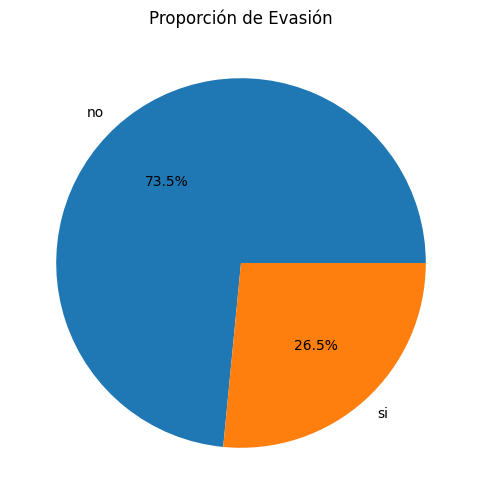

In [1168]:
conteo = datos_final["Churn"].value_counts().sort_index()

plt.figure(figsize=(6,6))
plt.pie(
    conteo,
    labels=["no", "si"],
    autopct="%1.1f%%"
)
plt.title("Proporción de Evasión")
plt.ylabel("")
plt.show()

###Recuento de evasión por variables categóricas

In [1169]:
datos_final.groupby("gender")["Churn"].mean().round(3) * 100

,Churn
gender,
Female,26.9
Male,26.2


In [1170]:
datos_final.groupby("Contract")["Churn"].mean().round(3) * 100

,Churn
Contract,
Month-to-month,42.7
One year,11.3
Two year,2.8


In [1171]:
datos_final.groupby("PaymentMethod")["Churn"].mean().round(3) * 100

,Churn
PaymentMethod,
Bank transfer (automatic),16.7
Credit card (automatic),15.2
Electronic check,45.3
Mailed check,19.1


In [1172]:
datos_final.groupby("Partner")["Churn"].mean().round(3) * 100
# 33% no -  19.7% si

,Churn
Partner,
0,33.0
1,19.7


##Conteo de evasión por variables numéricas

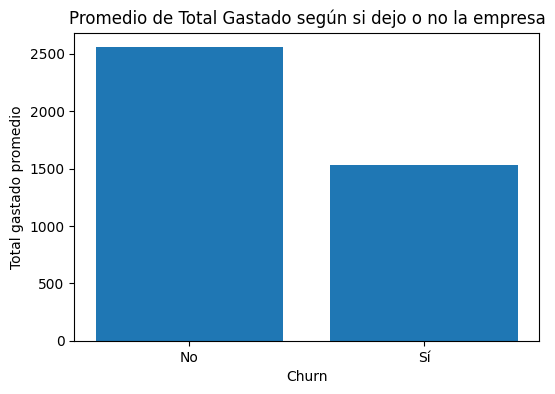

In [1173]:
total_promedio = datos_final.groupby("Churn")["Charges.Total"].mean().round(2)
plt.figure(figsize=(6,4))

plt.bar(total_promedio.index, total_promedio.values)

plt.xticks([0,1], ["No", "Sí"])  # Cambiamos etiquetas
plt.title("Promedio de Total Gastado según si dejo o no la empresa")
plt.xlabel("Churn")
plt.ylabel("Total gastado promedio")

plt.show()

<Figure size 600x400 with 0 Axes>

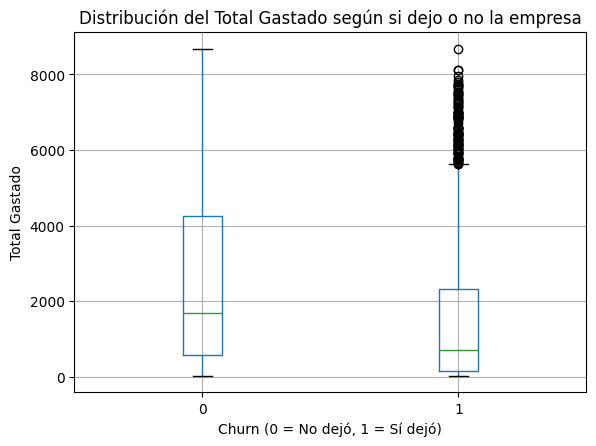

In [1174]:
plt.figure(figsize=(6,4))
datos_final.boxplot(column="Charges.Total", by="Churn")

plt.title("Distribución del Total Gastado según si dejo o no la empresa")
plt.suptitle("")
plt.xlabel("Churn (0 = No dejó, 1 = Sí dejó)")
plt.ylabel("Total Gastado")
plt.show()

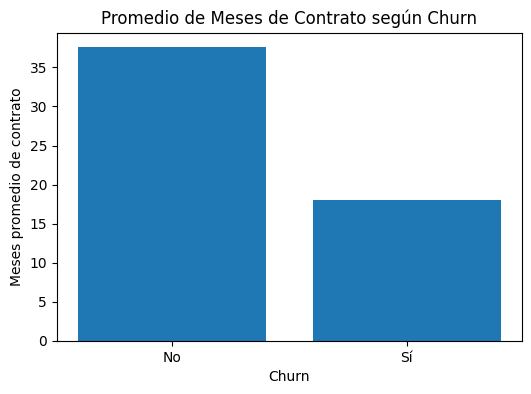

In [1175]:
tenure_promedio = datos_final.groupby("Churn")["tenure"].mean().round(2)

plt.figure(figsize=(6,4))

plt.bar(tenure_promedio.index, tenure_promedio.values)

plt.xticks([0,1], ["No", "Sí"])  # Cambiamos las etiquetas del eje X
plt.title("Promedio de Meses de Contrato según Churn")
plt.xlabel("Churn")
plt.ylabel("Meses promedio de contrato")

plt.show()

<Figure size 600x400 with 0 Axes>

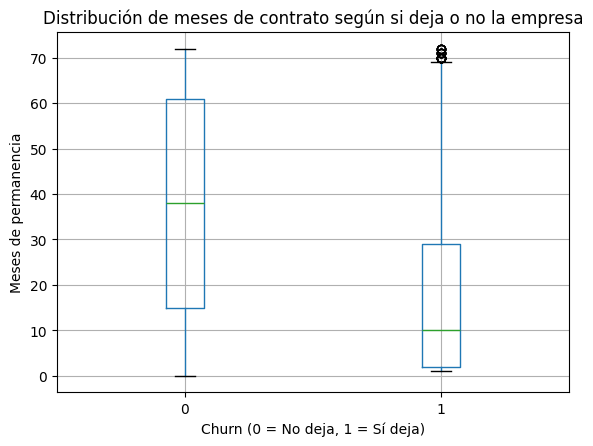

In [1176]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

datos_final.boxplot(column="tenure", by="Churn")

plt.title("Distribución de meses de contrato según si deja o no la empresa")
plt.suptitle("")
plt.xlabel("Churn (0 = No deja, 1 = Sí deja)")
plt.ylabel("Meses de permanencia")

plt.show()

##Informe final

##Introducción

El objetivo de este análisis es comprender los factores que influyen en la evasión de clientes en Telecom X.
En este proyecto se realizó un proceso completo de análisis de datos utilizando Python, Pandas y Matplotlib. A partir de los datos disponibles sobre los clientes, se buscó identificar patrones y variables que puedan estar asociadas con una mayor probabilidad de cancelación del servicio.

##Limpieza y Tratamiento de Datos

Los datos fueron obtenidos desde una API en formato JSON y cargados en un DataFrame utilizando la biblioteca Pandas. Debido a que el archivo contenía estructuras anidadas, se utilizó **json_normalize()** para convertir esas estructuras en columnas independientes y así facilitar su análisis.
Posteriormente se realizó una validación de los datos para detectar valores nulos, duplicados y errores de formato. Algunas columnas fueron transformadas para mejorar su uso analítico, como la conversión de variables categóricas a valores binarios y la transformación de la columna **Charges.Total** a tipo numérico. Además, se creó una nueva variable llamada **Cuentas_Diarias**, calculada a partir del cargo mensual.

##Análisis exploratorio de datos

El análisis mostró que aproximadamente **26.5%** de los clientes cancelaron el servicio, mientras que el **73.5%** permanecen en la empresa.

Al analizar variables categóricas se observó que el tipo de contrato tiene una fuerte relación con si dejaron el serivicio. Los clientes con contratos mensuales presentan una tasa de cancelación mucho mayor que aquellos con contratos de uno o dos años. También se identificó que el método de pago **Electronic Check** está asociado con mayores niveles de evasión.
Por otro lado, el análisis de variables numéricas mostró que los clientes que cancelan el servicio tienen, en promedio, menos meses de permanencia y menor gasto total acumulado que los clientes que continúan en la empresa. Esto sugiere que los clientes nuevos tienen mayor probabilidad de abandonar el servicio.

##Conclusiones

A partir del análisis realizado se identificaron varios factores asociados con la evasión de clientes. Los contratos mensuales presentan las tasas más altas de cancelación, mientras que los contratos de mayor duración muestran una mayor retención. Además, los clientes con menor tiempo en la empresa tienden a cancelar con mayor frecuencia.
Estos resultados indican que el compromiso del cliente con el servicio, reflejado en la duración del contrato y el tiempo de permanencia, es un factor clave en la retención.

##Recomendaciones

Con base en los resultados obtenidos, se recomienda incentivar contratos de mayor duración mediante descuentos o beneficios para los clientes. También sería útil implementar estrategias de retención durante los primeros meses de servicio, ya que es en ese período donde se observa mayor riesgo de cancelación. Finalmente, promover métodos de pago automáticos podría contribuir a reducir la tasa de evasión.

# Parte 2


## Preparacion de los datos

In [1177]:
datos_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   int64  
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   int64  
 5   Dependents        7043 non-null   int64  
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   int64  
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 
 17  

In [1178]:
datos_final = datos_final.drop(columns=['customerID'])

datos_final.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0,Female,0,1,1,9,1,No,DSL,No,Yes,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19
1,0,Male,0,0,0,9,1,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,1,Male,0,0,0,4,1,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,1,Male,1,1,0,13,1,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,1,Female,1,1,0,3,1,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.80


In [1179]:
# Ver tipos de datos
datos_final.dtypes

,0
Churn,int64
gender,object
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [1180]:
# identificar variables categóricas
categoricas = datos_final.select_dtypes(include='object').columns

categoricas

Index(['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaymentMethod'],
      dtype='object')

In [1181]:
# aplicar one-hot encoding

datos_encoded = pd.get_dummies(datos_final, columns=categoricas, drop_first=True)

datos_encoded.head()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias,gender_Male,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,1,9,1,1,65.6,593.30,2.19,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,True,False,False,False,True
1,0,0,0,0,9,1,0,59.9,542.40,2.00,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True
2,1,0,0,0,4,1,1,73.9,280.85,2.46,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False
3,1,1,1,0,13,1,1,98.0,1237.85,3.27,True,False,False,True,False,False,False,False,True,False,True,False,False,False,True,False,True,False,False,False,True,False
4,1,1,1,0,3,1,1,83.9,267.40,2.80,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,True


In [1182]:
datos_encoded.dtypes

,0
Churn,int64
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
PaperlessBilling,int64
Charges.Monthly,float64
Charges.Total,float64
Cuentas_Diarias,float64


In [1183]:
datos_encoded.shape

(7043, 32)

In [1184]:
# conteo absoluto de la variable objetivo
datos_encoded["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


In [1185]:
# proporción de cada clase en porcentaje
proporcion_churn = round(datos_encoded["Churn"].value_counts(normalize=True) * 100, 2)
proporcion_churn

,proportion
Churn,
0,73.46
1,26.54


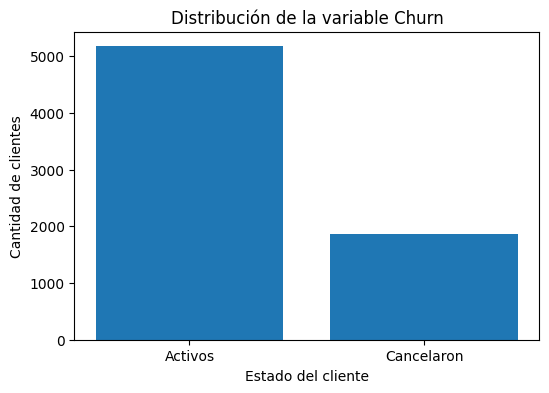

In [1186]:
conteo = datos_encoded["Churn"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(conteo.index, conteo.values)

plt.xticks([0,1], ["Activos", "Cancelaron"])
plt.title("Distribución de la variable Churn")
plt.xlabel("Estado del cliente")
plt.ylabel("Cantidad de clientes")

plt.show()

Se calculó la proporción de clientes que cancelaron el servicio en relación con aquellos que permanecieron activos utilizando value_counts().

Los resultados muestran que la mayoría de los registros corresponde a clientes que permanecen en la empresa, mientras que una proporción menor corresponde a clientes que cancelaron el servicio. Esto indica la presencia de un desbalance entre clases.

In [1187]:
# Variables explicativas
X = datos_encoded.drop("Churn", axis=1)

# Variable objetivo
y = datos_encoded["Churn"]

print(X.shape)
print(y.shape)

(7043, 31)
(7043,)


In [1188]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape, y_train.shape)
print("Prueba:", X_test.shape, y_test.shape)

Entrenamiento: (4930, 31) (4930,)
Prueba: (2113, 31) (2113,)


In [1189]:
# Porcentaje
round(y_train.value_counts(normalize=True) * 100, 2)

,proportion
Churn,
0,73.47
1,26.53


In [1190]:
from imblearn.under_sampling import RandomUnderSampler

# Crear undersampler
rus = RandomUnderSampler(random_state=42)

# Aplicar balanceo solo en entrenamiento
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

# Verificar resultado
print(y_train_under.value_counts())
print(round(y_train_under.value_counts(normalize=True) * 100, 2))

Churn
0    1308
1    1308
Name: count, dtype: int64
Churn
0    50.0
1    50.0
Name: proportion, dtype: float64


In [1191]:
from imblearn.over_sampling import RandomOverSampler

# Crear oversampler
ros = RandomOverSampler(random_state=42)

# Aplicar balanceo solo en entrenamiento
X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

# Verificar resultado
print(y_train_over.value_counts())
print(round(y_train_over.value_counts(normalize=True) * 100, 2))

Churn
0    3622
1    3622
Name: count, dtype: int64
Churn
0    50.0
1    50.0
Name: proportion, dtype: float64


In [1192]:
X_train.isna().sum()

,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
PaperlessBilling,0
Charges.Monthly,0
Charges.Total,9
Cuentas_Diarias,0
gender_Male,0


In [1193]:
# rellenar valores faltantes con la mediana
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

In [1194]:
from imblearn.over_sampling import SMOTE

# Crear objeto SMOTE
smote = SMOTE(random_state=42)

# Aplicar balanceo solo en entrenamiento
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Verificar resultado
print(y_train_smote.value_counts())
print(round(y_train_smote.value_counts(normalize=True) * 100, 2))

Churn
0    3622
1    3622
Name: count, dtype: int64
Churn
0    50.0
1    50.0
Name: proportion, dtype: float64


In [1195]:
print("Original train:", X_train.shape, y_train.shape)
print("Undersampling:", X_train_under.shape, y_train_under.shape)
print("Oversampling:", X_train_over.shape, y_train_over.shape)
print("SMOTE:", X_train_smote.shape, y_train_smote.shape)

Original train: (4930, 31) (4930,)
Undersampling: (2616, 31) (2616,)
Oversampling: (7244, 31) (7244,)
SMOTE: (7244, 31) (7244,)


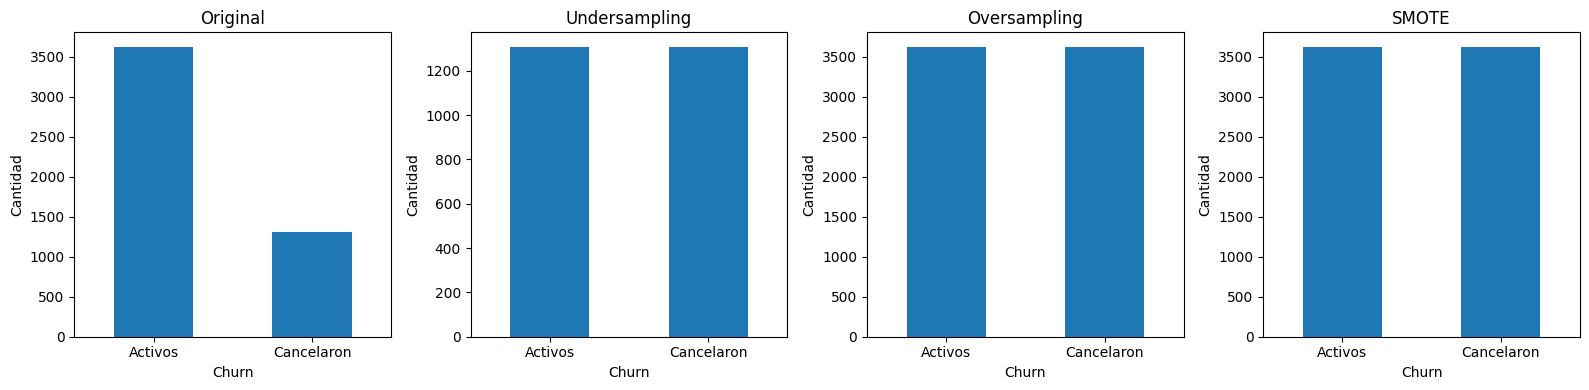

In [1196]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16,4))

y_train.value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Original")
y_train_under.value_counts().sort_index().plot(kind="bar", ax=axes[1], title="Undersampling")
y_train_over.value_counts().sort_index().plot(kind="bar", ax=axes[2], title="Oversampling")
y_train_smote.value_counts().sort_index().plot(kind="bar", ax=axes[3], title="SMOTE")

for ax in axes:
    ax.set_xticklabels(["Activos", "Cancelaron"], rotation=0)
    ax.set_xlabel("Churn")
    ax.set_ylabel("Cantidad")

plt.tight_layout()
plt.show()

In [1197]:
# identificar variables numéricas
numericas = X_train_smote.select_dtypes(include=['int64','float64','bool']).columns

numericas

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
       'PaperlessBilling', 'Charges.Monthly', 'Charges.Total',
       'Cuentas_Diarias', 'gender_Male', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No internet service',
       'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [1198]:
X_train_smote.describe()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7244.000000,7244.000000,7244.000000,7244.000000,7244.000000,7244.000000,7244.000000,7244.000000,7244.000000
mean,0.136665,0.371618,0.216317,27.451408,0.902678,0.606295,68.143903,2038.175399,2.271457
std,0.343517,0.483270,0.411761,23.943482,0.296416,0.488605,28.639000,2179.447406,0.954738
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.400000,18.800000,0.610000
25%,0.000000,0.000000,0.000000,5.000000,1.000000,0.000000,45.873612,269.601275,1.530000
50%,0.000000,0.000000,0.000000,21.000000,1.000000,1.000000,74.800000,1155.850000,2.491535
75%,0.000000,1.000000,0.000000,48.000000,1.000000,1.000000,91.000000,3270.141561,3.031325
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


In [1199]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


In [1200]:
X_train_scaled = scaler.fit_transform(X_train_smote)

X_test_scaled = scaler.transform(X_test)

In [1201]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train_smote.columns)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns)

In [1202]:
X_train_scaled.describe()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias,gender_Male,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,7.244000e+03,7.244000e+03,7.244000e+03,7.244000e+03,7.244000e+03,7.244000e+03,7.244000e+03,7.244000e+03,7.244000e+03,7.244000e+03,7.244000e+03,7.244000e+03,7.244000e+03,7.244000e+03,7.244000e+03,7.244000e+03,7.244000e+03,7.244000e+03,7.244000e+03,7.244000e+03,7.244000e+03,7.244000e+03,7.244000e+03,7.244000e+03,7.244000e+03,7.244000e+03,7.244000e+03,7.244000e+03,7.244000e+03,7.244000e+03,7.244000e+03
mean,-1.569393e-17,-3.138786e-17,9.416359e-17,4.708179e-17,9.808707e-17,-1.211375e-16,1.255514e-16,-3.138786e-17,-2.118681e-16,-5.492876e-17,-3.433047e-17,-6.277572e-17,6.277572e-17,7.846966e-17,7.846966e-17,-7.258443e-17,7.846966e-17,4.315831e-17,7.846966e-17,5.100528e-17,7.846966e-17,7.062269e-17,7.846966e-17,-2.354090e-17,7.846966e-17,-9.416359e-17,-2.746438e-17,-6.277572e-17,-1.275132e-17,-6.277572e-17,-6.669921e-17
std,1.000069e+00,1.000069e+00,1.000069e+00,1.000069e+00,1.000069e+00,1.000069e+00,1.000069e+00,1.000069e+00,1.000069e+00,1.000069e+00,1.000069e+00,1.000069e+00,1.000069e+00,1.000069e+00,1.000069e+00,1.000069e+00,1.000069e+00,1.000069e+00,1.000069e+00,1.000069e+00,1.000069e+00,1.000069e+00,1.000069e+00,1.000069e+00,1.000069e+00,1.000069e+00,1.000069e+00,1.000069e+00,1.000069e+00,1.000069e+00,1.000069e+00
min,-3.978677e-01,-7.690178e-01,-5.253818e-01,-1.146588e+00,-3.045518e+00,-1.240956e+00,-1.737049e+00,-9.266178e-01,-1.740343e+00,-1.153585e+00,-3.283514e-01,-9.754530e-01,-1.091103e+00,-4.542335e-01,-4.542335e-01,-6.211932e-01,-4.542335e-01,-7.572413e-01,-4.542335e-01,-7.742545e-01,-4.542335e-01,-6.329445e-01,-4.542335e-01,-8.927893e-01,-4.542335e-01,-9.000527e-01,-4.857639e-01,-4.637117e-01,-5.275204e-01,-9.615344e-01,-5.543873e-01
25%,-3.978677e-01,-7.690178e-01,-5.253818e-01,-9.377482e-01,3.283514e-01,-1.240956e+00,-7.776748e-01,-8.115342e-01,-7.766615e-01,-1.153585e+00,-3.283514e-01,-9.754530e-01,-1.091103e+00,-4.542335e-01,-4.542335e-01,-6.211932e-01,-4.542335e-01,-7.572413e-01,-4.542335e-01,-7.742545e-01,-4.542335e-01,-6.329445e-01,-4.542335e-01,-8.927893e-01,-4.542335e-01,-9.000527e-01,-4.857639e-01,-4.637117e-01,-5.275204e-01,-9.615344e-01,-5.543873e-01
50%,-3.978677e-01,-7.690178e-01,-5.253818e-01,-2.694618e-01,3.283514e-01,8.058303e-01,2.324298e-01,-4.048670e-01,2.305270e-01,8.668625e-01,-3.283514e-01,-9.754530e-01,9.165041e-01,-4.542335e-01,-4.542335e-01,-6.211932e-01,-4.542335e-01,-7.572413e-01,-4.542335e-01,-7.742545e-01,-4.542335e-01,-6.329445e-01,-4.542335e-01,-8.927893e-01,-4.542335e-01,-9.000527e-01,-4.857639e-01,-4.637117e-01,-5.275204e-01,-9.615344e-01,-5.543873e-01
75%,-3.978677e-01,1.300360e+00,-5.253818e-01,8.582716e-01,3.283514e-01,8.058303e-01,7.981310e-01,5.653044e-01,7.959469e-01,8.668625e-01,-3.283514e-01,1.025165e+00,9.165041e-01,-4.542335e-01,-4.542335e-01,1.609805e+00,-4.542335e-01,1.320583e+00,-4.542335e-01,1.291565e+00,-4.542335e-01,1.579917e+00,-4.542335e-01,1.120085e+00,-4.542335e-01,1.111046e+00,-4.857639e-01,-4.637117e-01,-5.275204e-01,1.040004e+00,-5.543873e-01
max,2.513398e+00,1.300360e+00,1.903378e+00,1.860701e+00,3.283514e-01,8.058303e-01,1.767156e+00,3.049894e+00,1.768715e+00,8.668625e-01,3.045518e+00,1.025165e+00,9.165041e-01,2.201511e+00,2.201511e+00,1.609805e+00,2.201511e+00,1.320583e+00,2.201511e+00,1.291565e+00,2.201511e+00,1.579917e+00,2.201511e+00,1.120085e+00,2.201511e+00,1.111046e+00,2.058613e+00,2.1565

## Analisis de correlaciòn

In [1203]:
# calcular matriz de correlación
correlacion = datos_encoded.corr()

correlacion.head()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias,gender_Male,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
Churn,1.000000,0.150889,-0.150448,-0.164221,-0.352229,0.011942,0.191825,0.193356,-0.199484,0.193412,-0.008612,-0.011942,0.040102,0.308020,-0.227890,-0.227890,-0.171226,-0.227890,-0.082255,-0.227890,-0.066160,-0.227890,-0.164674,-0.227890,0.063228,-0.227890,0.061382,-0.177820,-0.302253,-0.134302,0.301919,-0.091683
SeniorCitizen,0.150889,1.000000,0.016479,-0.211185,0.016567,0.008576,0.156530,0.220173,0.102411,0.220147,-0.001874,-0.008576,0.142948,0.255338,-0.182742,-0.182742,-0.038653,-0.182742,0.066572,-0.182742,0.059428,-0.182742,-0.060625,-0.182742,0.105378,-0.182742,0.120176,-0.046262,-0.117000,-0.024135,0.171718,-0.153477
Partner,-0.150448,0.016479,1.000000,0.452676,0.379697,0.017706,-0.014877,0.096848,0.319072,0.096909,-0.001808,-0.017706,0.142057,0.000304,0.000615,0.000615,0.143106,0.000615,0.141498,0.000615,0.153786,0.000615,0.119999,0.000615,0.124666,0.000615,0.117412,0.082783,0.248091,0.082029,-0.083852,-0.095125
Dependents,-0.164221,-0.211185,0.452676,1.000000,0.159712,-0.001762,-0.111377,-0.113890,0.064653,-0.113939,0.010517,0.001762,-0.024526,-0.165818,0.139812,0.139812,0.080972,0.139812,0.023671,0.139812,0.013963,0.139812,0.063268,0.139812,-0.016558,0.139812,-0.039741,0.068368,0.204613,0.060267,-0.150642,0.059071
tenure,-0.352229,0.016567,0.379697,0.159712,1.000000,0.008448,0.006152,0.247900,0.825880,0.247910,0.005106,-0.008448,0.331941,0.019720,-0.039062,-0.039062,0.327203,-0.039062,0.360277,-0.039062,0.360653,-0.039062,0.324221,-0.039062,0.279756,-0.039062,0.286111,0.202570,0.558533,0.233006,-0.208363,-0.233852


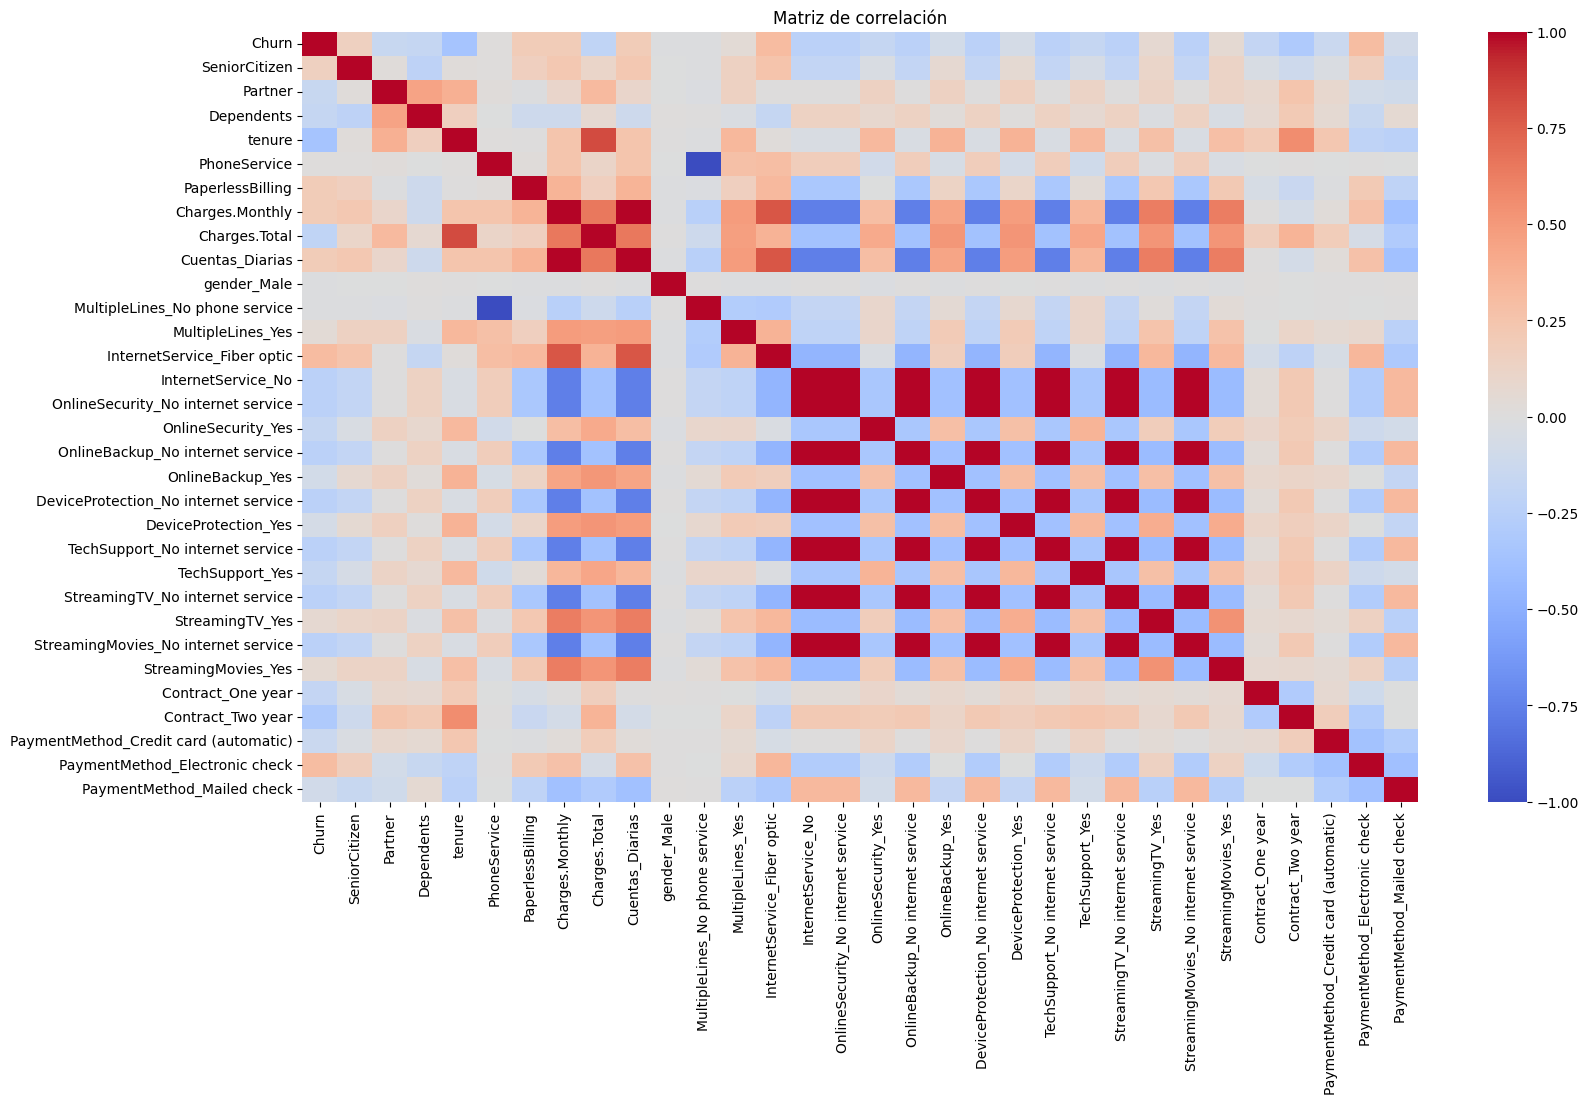

In [1204]:
plt.figure(figsize=(18,10))
sns.heatmap(correlacion, cmap="coolwarm", center=0)

plt.title("Matriz de correlación")
plt.show()

In [1205]:
# correlación de todas las variables con Churn
correlacion_churn = correlacion["Churn"].sort_values(ascending=False)

correlacion_churn

,Churn
Churn,1.000000
InternetService_Fiber optic,0.308020
PaymentMethod_Electronic check,0.301919
Cuentas_Diarias,0.193412
Charges.Monthly,0.193356
PaperlessBilling,0.191825
SeniorCitizen,0.150889
StreamingTV_Yes,0.063228
StreamingMovies_Yes,0.061382
MultipleLines_Yes,0.040102


In [1206]:
# variables con mayor correlación positiva con Churn
correlacion_churn.head()

,Churn
Churn,1.000000
InternetService_Fiber optic,0.308020
PaymentMethod_Electronic check,0.301919
Cuentas_Diarias,0.193412
Charges.Monthly,0.193356


In [1207]:
# variables con mayor correlación negativa con Churn
correlacion_churn.tail()

,Churn
DeviceProtection_No internet service,-0.227890
StreamingMovies_No internet service,-0.227890
TechSupport_No internet service,-0.227890
Contract_Two year,-0.302253
tenure,-0.352229


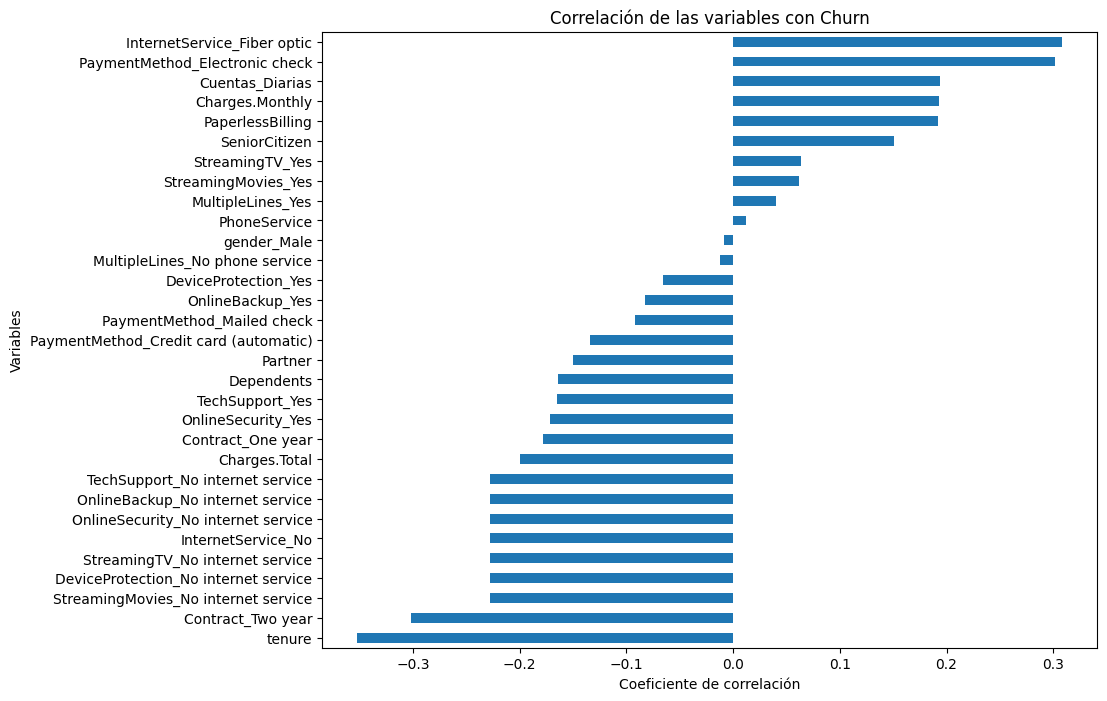

In [1208]:
plt.figure(figsize=(10,8))

correlacion_churn.drop("Churn").sort_values().plot(kind="barh")

plt.title("Correlación de las variables con Churn")
plt.xlabel("Coeficiente de correlación")
plt.ylabel("Variables")
plt.show()

In [1209]:
# variables con correlación relevante (ejemplo: mayor a 0.2 en valor absoluto)
variables_relevantes = correlacion_churn[abs(correlacion_churn) > 0.2]

variables_relevantes

,Churn
Churn,1.000000
InternetService_Fiber optic,0.308020
PaymentMethod_Electronic check,0.301919
InternetService_No,-0.227890
StreamingTV_No internet service,-0.227890
OnlineSecurity_No internet service,-0.227890
OnlineBackup_No internet service,-0.227890
DeviceProtection_No internet service,-0.227890
StreamingMovies_No internet service,-0.227890
TechSupport_No internet service,-0.227890


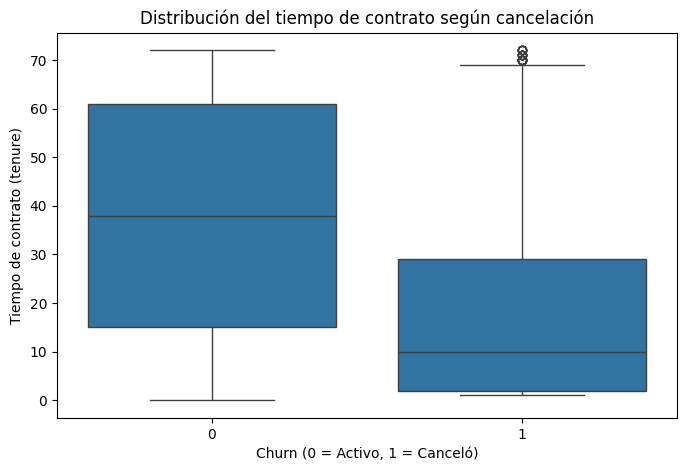

In [1210]:
plt.figure(figsize=(8,5))
sns.boxplot(data=datos_encoded, x="Churn", y="tenure")

plt.title("Distribución del tiempo de contrato según cancelación")
plt.xlabel("Churn (0 = Activo, 1 = Canceló)")
plt.ylabel("Tiempo de contrato (tenure)")
plt.show()

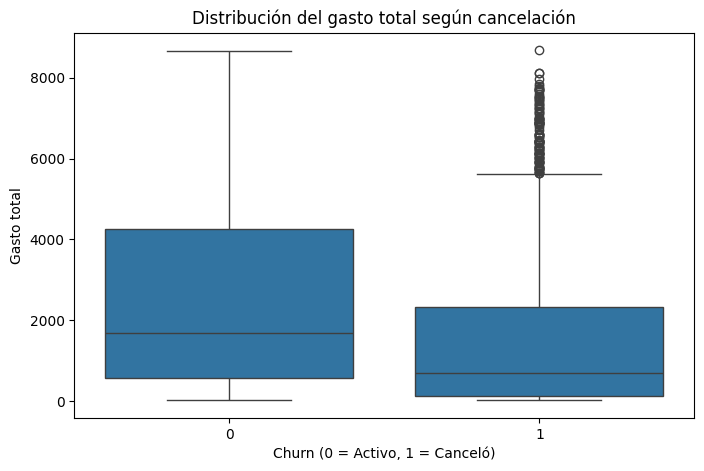

In [1211]:
plt.figure(figsize=(8,5))
sns.boxplot(data=datos_encoded, x="Churn", y="Charges.Total")

plt.title("Distribución del gasto total según cancelación")
plt.xlabel("Churn (0 = Activo, 1 = Canceló)")
plt.ylabel("Gasto total")
plt.show()

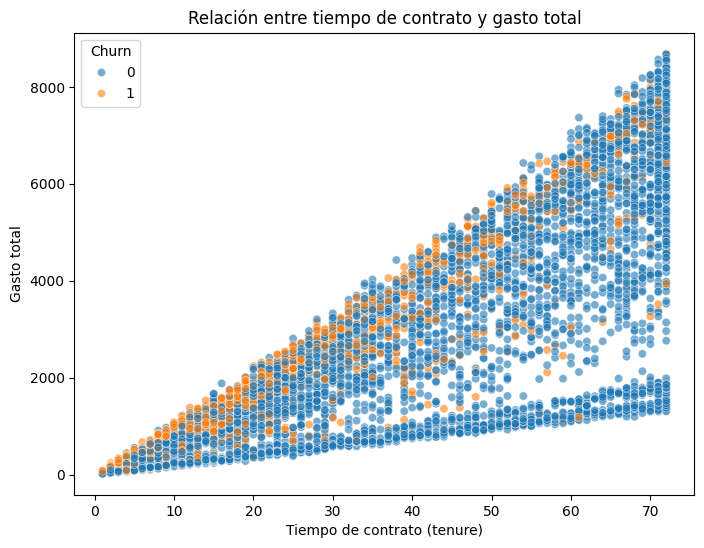

In [1212]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=datos_encoded,
    x="tenure",
    y="Charges.Total",
    hue="Churn",
    alpha=0.6
)

plt.title("Relación entre tiempo de contrato y gasto total")
plt.xlabel("Tiempo de contrato (tenure)")
plt.ylabel("Gasto total")
plt.show()

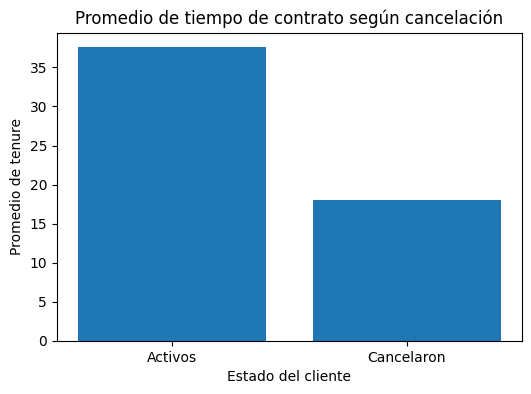

In [1213]:
tenure_promedio = datos_encoded.groupby("Churn")["tenure"].mean()

plt.figure(figsize=(6,4))
plt.bar(tenure_promedio.index, tenure_promedio.values)

plt.xticks([0,1], ["Activos", "Cancelaron"])
plt.title("Promedio de tiempo de contrato según cancelación")
plt.xlabel("Estado del cliente")
plt.ylabel("Promedio de tenure")
plt.show()

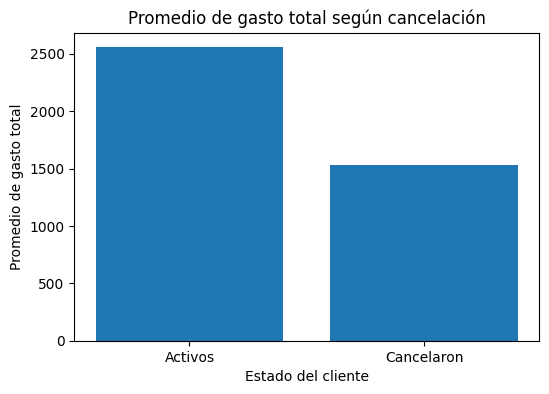

In [1214]:
gasto_promedio = datos_encoded.groupby("Churn")["Charges.Total"].mean()

plt.figure(figsize=(6,4))
plt.bar(gasto_promedio.index, gasto_promedio.values)

plt.xticks([0,1], ["Activos", "Cancelaron"])
plt.title("Promedio de gasto total según cancelación")
plt.xlabel("Estado del cliente")
plt.ylabel("Promedio de gasto total")
plt.show()

## Modelado predictivo

In [1215]:
# Variables predictoras
X = datos_encoded.drop("Churn", axis=1)

# Variable objetivo
y = datos_encoded["Churn"]

In [1216]:
print("Distribución de churn en entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nDistribución de churn en prueba:")
print(y_test.value_counts(normalize=True))

Distribución de churn en entrenamiento:
Churn
0    0.734686
1    0.265314
Name: proportion, dtype: float64

Distribución de churn en prueba:
Churn
0    0.734501
1    0.265499
Name: proportion, dtype: float64


In [1217]:
X_train.isna().sum()

,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
PaperlessBilling,0
Charges.Monthly,0
Charges.Total,0
Cuentas_Diarias,0
gender_Male,0


In [1218]:
print(y_train_smote.value_counts())
print(round(y_train_smote.value_counts(normalize=True)*100,2))

Churn
0    3622
1    3622
Name: count, dtype: int64
Churn
0    50.0
1    50.0
Name: proportion, dtype: float64


In [1219]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_train_smote:", X_train_smote.shape)
print("y_train_smote:", y_train_smote.shape)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train: (4930, 31)
y_train: (4930,)
X_train_smote: (7244, 31)
y_train_smote: (7244,)
X_train_scaled: (7244, 31)
X_test_scaled: (2113, 31)


In [1220]:
print("X_train_scaled:", X_train_scaled.shape)
print("y_train_smote:", y_train_smote.shape)

X_train_scaled: (7244, 31)
y_train_smote: (7244,)


In [1223]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("----------------------------------------------------------------------------------------------------------------------------------")
print("MODELO 1 — REGRESIÓN LOGÍSTICA")
print("----------------------------------------------------------------------------------------------------------------------------------")
modelo_logistico = LogisticRegression(max_iter=1000, random_state=42)

modelo_logistico.fit(X_train_scaled, y_train_smote)

y_pred_log = modelo_logistico.predict(X_test_scaled)

print("Accuracy - Regresión Logística:")
print(accuracy_score(y_test, y_pred_log))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_log))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_log))
print("----------------------------------------------------------------------------------------------------------------------------------")
print("MODELO 2 — RANDOM FOREST")
print("----------------------------------------------------------------------------------------------------------------------------------")
modelo_rf = RandomForestClassifier(n_estimators=200, random_state=42)

modelo_rf.fit(X_train_smote, y_train_smote)

y_pred_rf = modelo_rf.predict(X_test)

print("\nRandom Forest:")
print(accuracy_score(y_test, y_pred_rf))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf))

----------------------------------------------------------------------------------------------------------------------------------
MODELO 1 — REGRESIÓN LOGÍSTICA
----------------------------------------------------------------------------------------------------------------------------------
Accuracy - Regresión Logística:
0.7510648367250355

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.86      0.79      0.82      1552
           1       0.52      0.66      0.58       561

    accuracy                           0.75      2113
   macro avg       0.69      0.72      0.70      2113
weighted avg       0.77      0.75      0.76      2113


Matriz de confusión:
[[1219  333]
 [ 193  368]]
----------------------------------------------------------------------------------------------------------------------------------
MODELO 2 — RANDOM FOREST
-------------------------------------------------------------------------------------------------

In [1225]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred_log = modelo_logistico.predict(X_test_scaled)

y_pred_rf = modelo_rf.predict(X_test)

In [1226]:
print("=== REGRESIÓN LOGÍSTICA ===")

accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print("Accuracy:", accuracy_log)
print("Precision:", precision_log)
print("Recall:", recall_log)
print("F1-score:", f1_log)

=== REGRESIÓN LOGÍSTICA ===
Accuracy: 0.7510648367250355
Precision: 0.5249643366619116
Recall: 0.6559714795008913
F1-score: 0.5832012678288431


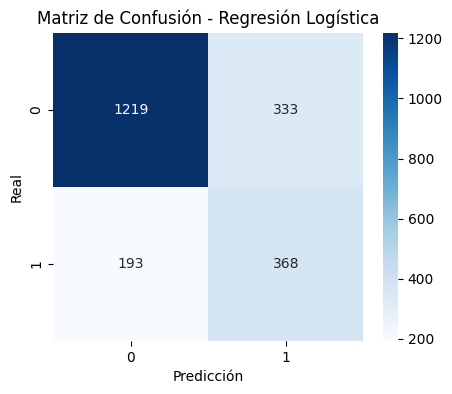

In [1227]:
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [1229]:
print("=== RANDOM FOREST ===")

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1-score:", f1_rf)

=== RANDOM FOREST ===
Accuracy: 0.7685754850922859
Precision: 0.5608108108108109
Recall: 0.5918003565062389
F1-score: 0.5758889852558543


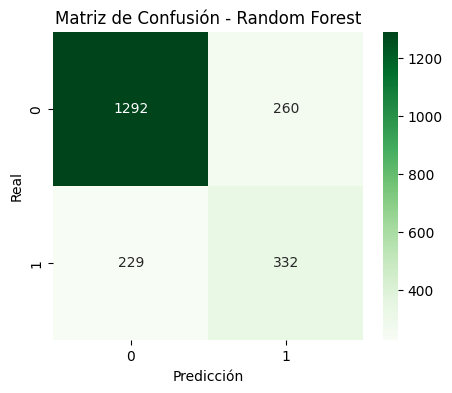

In [1230]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")

plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [1231]:
print("Reporte Regresión Logística")
print(classification_report(y_test, y_pred_log))

print("\nReporte Random Forest")
print(classification_report(y_test, y_pred_rf))

Reporte Regresión Logística
              precision    recall  f1-score   support

           0       0.86      0.79      0.82      1552
           1       0.52      0.66      0.58       561

    accuracy                           0.75      2113
   macro avg       0.69      0.72      0.70      2113
weighted avg       0.77      0.75      0.76      2113


Reporte Random Forest
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1552
           1       0.56      0.59      0.58       561

    accuracy                           0.77      2113
   macro avg       0.71      0.71      0.71      2113
weighted avg       0.77      0.77      0.77      2113



In [1232]:
resultados = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Random Forest"],
    "Accuracy": [accuracy_log, accuracy_rf],
    "Precision": [precision_log, precision_rf],
    "Recall": [recall_log, recall_rf],
    "F1-score": [f1_log, f1_rf]})

resultados

,Modelo,Accuracy,Precision,Recall,F1-score
0,Regresión Logística,0.751065,0.524964,0.655971,0.583201
1,Random Forest,0.768575,0.560811,0.591800,0.575889


## Interpretaciones y conclusiones

Análisis de variables relevantes

Después de entrenar los modelos predictivos, se analizó la importancia de las variables para comprender cuáles factores influyen más en la cancelación de clientes.
En el caso de la Regresión Logística, se analizaron los coeficientes del modelo. Estos coeficientes indican cómo cada variable afecta la probabilidad de cancelación. Valores positivos sugieren que la variable aumenta la probabilidad de churn, mientras que valores negativos indican un efecto protector contra la cancelación.
Por otro lado, en el modelo de Random Forest, se utilizó la métrica de feature importance, que mide cuánto contribuye cada variable a reducir la impureza en los árboles de decisión. Las variables con mayor importancia son aquellas que ayudan más al modelo a separar clientes que cancelan de los que permanecen activos.

Al comparar ambos modelos, se observa que variables relacionadas con:
- Tiempo de contrato (tenure)
- Gasto total (Charges.Total)
- Tipo de contrato
- Servicios adicionales contratados.

aparecen consistentemente como factores relevantes en la predicción de la cancelación.
Estos resultados indican que los clientes con menor antigüedad, menores niveles de gasto acumulado o contratos más flexibles tienen mayor probabilidad de cancelar el servicio.

###Informe Final: Predicción de Cancelación de Clientes (Churn)
1. **Introducción**

El objetivo de este análisis fue desarrollar modelos predictivos capaces de identificar qué clientes presentan una mayor probabilidad de cancelar los servicios de la empresa Telecom X. La cancelación de clientes, conocida como churn, representa un problema crítico para las empresas de telecomunicaciones, ya que implica la pérdida de ingresos y un incremento en los costos asociados a la adquisición de nuevos clientes.

Para abordar este problema, se realizó un proceso completo de análisis de datos y modelado predictivo, que incluyó la preparación de los datos, el análisis exploratorio, la construcción de modelos de clasificación y la interpretación de las variables más relevantes en la predicción de la cancelación.

2. **Metodología**

El análisis se llevó a cabo en varias etapas. En primer lugar, se realizó un proceso de limpieza y preparación de los datos, eliminando variables que no aportaban valor predictivo, como identificadores únicos de clientes. Posteriormente, se transformaron las variables categóricas a formato numérico mediante técnicas de codificación, permitiendo su utilización en modelos de machine learning.

Debido al desbalance presente en la variable objetivo (cancelación), se aplicó la técnica de SMOTE (Synthetic Minority Over-sampling Technique) sobre el conjunto de entrenamiento para equilibrar las clases y mejorar la capacidad de los modelos para identificar clientes que cancelan el servicio.

Posteriormente, se dividió el conjunto de datos en conjuntos de entrenamiento y prueba, permitiendo evaluar el desempeño de los modelos en datos no utilizados durante el entrenamiento.

Se entrenaron dos modelos de clasificación con enfoques distintos:

Regresión Logística, un modelo lineal que requiere normalización de los datos y permite interpretar fácilmente la influencia de cada variable.

Random Forest, un modelo basado en árboles de decisión que no depende de la escala de los datos y permite capturar relaciones no lineales entre las variables.

El rendimiento de los modelos fue evaluado utilizando métricas como accuracy, precision, recall, F1-score y matriz de confusión, permitiendo comparar su capacidad para predecir la cancelación de clientes.

3. **Factores que influyen en la cancelación de clientes**

A partir del análisis exploratorio y del estudio de la importancia de variables en los modelos predictivos, se identificaron varios factores que muestran una relación significativa con la cancelación de clientes.

Uno de los factores más relevantes es el tiempo de permanencia del cliente en la empresa (tenure). Los resultados muestran que los clientes con menor antigüedad presentan una probabilidad considerablemente mayor de cancelar el servicio. Esto sugiere que el riesgo de churn es particularmente alto durante los primeros meses de relación con la empresa.

Otro factor importante es el gasto total acumulado del cliente (Charges.Total). Los clientes que cancelan el servicio tienden a presentar niveles de gasto acumulado más bajos, lo cual está relacionado con su menor permanencia en la empresa.

También se observaron diferencias asociadas al tipo de contrato. Los clientes con contratos mensuales (month-to-month) presentan tasas de cancelación significativamente mayores que aquellos con contratos de mayor duración, como contratos anuales o bianuales. Esto indica que los compromisos contractuales más largos funcionan como un mecanismo que reduce la probabilidad de abandono.

Finalmente, variables relacionadas con servicios adicionales, como soporte técnico, seguridad en línea o respaldo de datos, también muestran influencia en el comportamiento de cancelación. Los clientes que no utilizan estos servicios adicionales presentan una mayor tendencia a cancelar el servicio.

4. **Comparación de modelos predictivos**

Los modelos entrenados permitieron predecir la probabilidad de cancelación de los clientes a partir de sus características.

La Regresión Logística permitió interpretar directamente la influencia de cada variable a través de sus coeficientes, lo que facilita comprender cómo cada característica afecta la probabilidad de churn. Sin embargo, al ser un modelo lineal, su capacidad para capturar relaciones complejas entre variables es limitada.

Por otro lado, el modelo de Random Forest mostró una mayor capacidad para identificar patrones complejos en los datos. Este modelo combina múltiples árboles de decisión y permite capturar relaciones no lineales entre las variables, lo que suele mejorar el rendimiento predictivo en problemas reales.

En general, los modelos mostraron un desempeño adecuado para la predicción de la cancelación, siendo Random Forest el modelo que tiende a ofrecer mayor robustez y capacidad de generalización.

5. **Estrategias de retención basadas en los resultados**

A partir de los factores identificados, es posible proponer diversas estrategias orientadas a reducir la cancelación de clientes.

En primer lugar, dado que los clientes nuevos presentan una mayor probabilidad de cancelar el servicio, se recomienda implementar programas de fidelización durante los primeros meses de servicio, como beneficios iniciales, descuentos temporales o un acompañamiento más cercano en la etapa de onboarding.

En segundo lugar, considerando que los contratos mensuales presentan mayor tasa de cancelación, la empresa podría incentivar la adopción de contratos de mayor duración, ofreciendo beneficios económicos o descuentos a los clientes que opten por planes anuales o bianuales.

Otra estrategia consiste en promover la adopción de servicios adicionales, como soporte técnico o seguridad en línea. Estos servicios no solo generan ingresos adicionales, sino que también aumentan el nivel de integración del cliente con el ecosistema de la empresa, reduciendo la probabilidad de abandono.

Finalmente, el uso de modelos predictivos como los desarrollados en este análisis permite identificar clientes con alto riesgo de cancelación, lo que abre la posibilidad de implementar campañas de retención personalizadas antes de que el cliente decida abandonar el servicio.

6. **Conclusión**

El análisis realizado demuestra que es posible utilizar técnicas de análisis de datos y machine learning para identificar patrones asociados a la cancelación de clientes y anticipar comportamientos de abandono.

Variables como el tiempo de permanencia, el tipo de contrato, el gasto acumulado y la contratación de servicios adicionales juegan un papel clave en la predicción del churn. A través del uso de modelos predictivos, la empresa puede identificar clientes con mayor probabilidad de cancelar el servicio y desarrollar estrategias de retención más efectivas.

La implementación de este tipo de soluciones basadas en datos puede contribuir significativamente a mejorar la retención de clientes, optimizar los recursos de marketing y fortalecer la relación entre la empresa y sus usuarios.